In [108]:
# importing libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.base import clone
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, precision_score, recall_score, f1_score,
    precision_recall_curve
)
import joblib

In [48]:
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [49]:
### 1. Dropping the customerId column
df=df.drop("customerID",axis=1)
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


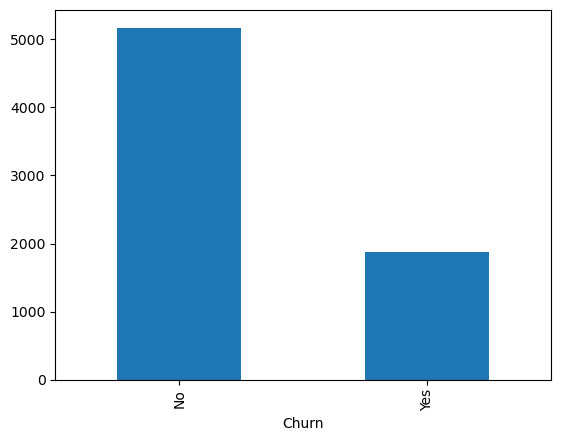

In [50]:
df["Churn"].value_counts().plot(kind="bar")
plt.show()

In [51]:
pd.crosstab(df['Contract'], df['Churn'])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [52]:
# shows people paying with  electronic check have a higher chances of stopping
pd.crosstab(df["PaymentMethod"],df["Churn"])

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


/var/folders/f8/gf9tprm90hndvc22qsv6drhm0000gn/T/ipykernel_1594/2612967330.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='tenure', y='Churn', palette='Set2')


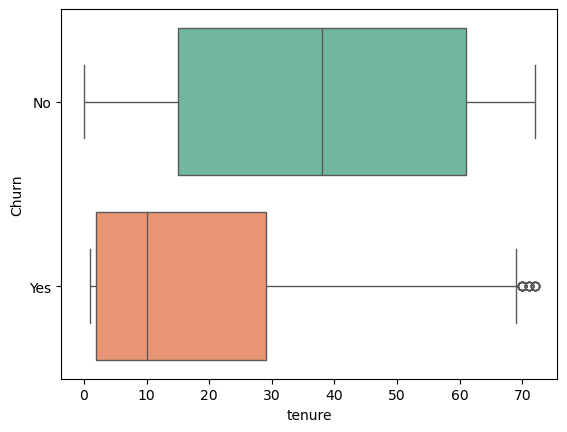

In [53]:
# shows that if the tenure grows more than 20 months the customer is more likely to continue
sns.boxplot(data=df, x='tenure', y='Churn', palette='Set2')
plt.show()

In [54]:
# checking the patterns between contract payment method and churn
df.groupby(["Contract","PaymentMethod","Churn"]).size().reset_index(name='Counts')

,Contract,PaymentMethod,Churn,Counts
0,Month-to-month,Bank transfer (automatic),No,388
1,Month-to-month,Bank transfer (automatic),Yes,201
2,Month-to-month,Credit card (automatic),No,365
3,Month-to-month,Credit card (automatic),Yes,178
4,Month-to-month,Electronic check,No,856
5,Month-to-month,Electronic check,Yes,994
6,Month-to-month,Mailed check,No,611
7,Month-to-month,Mailed check,Yes,282
8,One year,Bank transfer (automatic),No,353
9,One year,Bank transfer (automatic),Yes,38


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [56]:
## 2. Data cleaning converting total charges into int

df["TotalCharges"]=df["TotalCharges"].replace(" ",np.nan)
df=df.dropna(axis=0)
df["TotalCharges"]=df["TotalCharges"].astype(float)

/var/folders/f8/gf9tprm90hndvc22qsv6drhm0000gn/T/ipykernel_1594/1526216659.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["TotalCharges"]=df["TotalCharges"].astype(float)


In [64]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [77]:
# 2 split the model into train test split
y=df["Churn"].map({"Yes":1,"No":0})
x=df.drop("Churn",axis=1)

In [80]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [ ]:
# encoding the categorical columsn 

In [65]:
categorical_columns=["gender","Partner","Dependents","PhoneService","MultipleLines","InternetService","OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies","Contract","PaperlessBilling","PaymentMethod"]
numerical_columns=["tenure","MonthlyCharges","TotalCharges"]
categoric_encoder=OneHotEncoder(handle_unknown="ignore",drop="first")
numeric_encoder=StandardScaler()
preprocessor=ColumnTransformer([("one_hot",categoric_encoder,categorical_columns),
                                ("scaling",numeric_encoder,numerical_columns)],
                              remainder="passthrough")

In [69]:
# 4 modelling 

lr_model=LogisticRegression(class_weight="balanced",solver="lbfgs",max_iter=1000)
rf_model=RandomForestClassifier(class_weight="balanced",n_estimators=1000,n_jobs=-1)
dt_clf_model=DecisionTreeClassifier(class_weight="balanced",criterion="entropy")


In [70]:
models={"Logistic Regression": lr_model,"Random forest classifier":rf_model,"Decision tree classifier":dt_clf_model}
models

{'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000),
 'Random forest classifier': RandomForestClassifier(class_weight='balanced', n_estimators=1000, n_jobs=-1),
 'Decision tree classifier': DecisionTreeClassifier(class_weight='balanced', criterion='entropy')}

In [73]:
fp

In [81]:
fitted_pipeline={}

In [84]:
for name,model in models.items():
    pipe=clone(base_pipeline)
    pipe.set_params(model=model)
    pipe.fit(x_train,y_train)
    fitted_pipeline[name]=pipe

In [99]:
# Evaluating these 
results={}
 
for name, pipe in fitted_pipeline.items():
    preds = pipe.predict(x_test)
    probs = pipe.predict_proba(x_test)[:, 1]
 
    results[name] = {
        "preds": preds,
        "probs": probs,
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "roc_auc": roc_auc_score(y_test, probs)
    }
    print(classification_report(y_test, preds, target_names=["No Churn", "Churn"]))
    print("ROC-AUC:", round(results[name]["roc_auc"], 4))
 

              precision    recall  f1-score   support

    No Churn       0.91      0.71      0.80      1032
       Churn       0.50      0.80      0.62       375

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.75      1407

ROC-AUC: 0.8359
              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1032
       Churn       0.65      0.52      0.58       375

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407

ROC-AUC: 0.8179
              precision    recall  f1-score   support

    No Churn       0.83      0.80      0.81      1032
       Churn       0.50      0.55      0.52       375

    accuracy                           0.73      1407
   macro avg       0.66      0.67      0.67      1407
weighted avg       0.74      0.73      0.7

In [90]:
# comparision data frame
comparison_df = pd.DataFrame({
    name: {
        "Precision": res["precision"],
        "Recall": res["recall"],
        "F1": res["f1"],
        "ROC-AUC": res["roc_auc"]
    }
    for name, res in results.items()
}).T
 
print("\n===== Model Comparison =====")
print(comparison_df.round(3))


===== Model Comparison =====
                          Precision  Recall    F1  ROC-AUC
Logistic Regression           0.496   0.547  0.52    0.673
Random forest classifier      0.496   0.547  0.52    0.673
Decision tree classifier      0.496   0.547  0.52    0.673


In [103]:
final_model = LogisticRegression(class_weight="balanced", solver="lbfgs", max_iter=1000)
 
final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", final_model)
])
 
final_pipeline.fit(x_train, y_train)

/opt/anaconda3/envs/myenv/lib/python3.12/site-packages/sklearn/compose/_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('one_hot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod']),
                                                 ('scaling', StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [104]:
probs = final_pipeline.predict_proba(x_test)[:, 1]
 
precisions, recalls, thresholds = precision_recall_curve(y_test, probs)
 
target_recall = 0.80
idx = np.argmin(np.abs(recalls - target_recall))
chosen_threshold = float(thresholds[idx]) if idx < len(thresholds) else 0.5
 
print(f"Chosen threshold for ~{int(target_recall*100)}% recall: {chosen_threshold:.4f}")
 

Chosen threshold for ~80% recall: 0.5005


In [105]:
final_preds = (probs >= chosen_threshold).astype(int)
 
print("\n===== Final Model Performance (custom threshold) =====")
print(classification_report(y_test, final_preds, target_names=["No Churn", "Churn"]))
print("ROC-AUC:", round(roc_auc_score(y_test, probs), 4))
 


===== Final Model Performance (custom threshold) =====
              precision    recall  f1-score   support

    No Churn       0.91      0.71      0.80      1032
       Churn       0.50      0.80      0.62       375

    accuracy                           0.74      1407
   macro avg       0.70      0.76      0.71      1407
weighted avg       0.80      0.74      0.75      1407

ROC-AUC: 0.8359


In [106]:
# 7. FEATURE IMPORTANCE (coefficients) — for the report
# ---------------------------------------------------------------------
feature_names = final_pipeline.named_steps["preprocessor"].get_feature_names_out()
coefs = final_pipeline.named_steps["model"].coef_[0]
 
coef_df = pd.DataFrame({"feature": feature_names, "coefficient": coefs}) \
    .sort_values("coefficient", ascending=False)
 
print("\nTop churn-driving features:")
print(coef_df.head(10).to_string(index=False))


Top churn-driving features:
                                feature  coefficient
                  scaling__TotalCharges     0.779094
   one_hot__InternetService_Fiber optic     0.600893
          one_hot__PaperlessBilling_Yes     0.355140
one_hot__MultipleLines_No phone service     0.330353
one_hot__PaymentMethod_Electronic check     0.325227
                scaling__MonthlyCharges     0.187569
               remainder__SeniorCitizen     0.179303
             one_hot__MultipleLines_Yes     0.153667
           one_hot__StreamingMovies_Yes     0.127230
               one_hot__StreamingTV_Yes     0.106741


In [109]:
joblib.dump(final_pipeline, "churn_pipeline.pkl")   # single object: preprocessing + model
joblib.dump(chosen_threshold, "churn_threshold.pkl")
 

['churn_threshold.pkl']